In [1]:

import pandas as pd
import matplotlib.pyplot as plt


/var/folders/g_/_ldqv3dx6pscqdfvclt14pym0000gn/T/ipykernel_47046/1891906001.py:1: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [2]:

file_path = '/Users/maxbreitruck/Library/CloudStorage/OneDrive-UniversitaetSt.Gallen/001_IWI/Dissertation/Paper#2/NLP-Practices/export_df_ML.csv'  # Update with the correct path if necessary
data = pd.read_csv(file_path)


In [3]:

data.head()
data.describe()
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3255260 entries, 0 to 3255259
Data columns (total 19 columns):
 #   Column                       Dtype  
---  ------                       -----  
 0   Unnamed: 0                   int64  
 1   practice                     object 
 2   Company Name Full            object 
 3   month                        object 
 4   Supersector                  object 
 5   capability                   object 
 6   pillar                       object 
 7   cumulative_volume_per_month  float64
 8   p10                          float64
 9   p20                          float64
 10  p30                          float64
 11  p40                          float64
 12  p50                          float64
 13  p60                          float64
 14  p70                          float64
 15  p80                          float64
 16  p90                          float64
 17  p100                         float64
 18  score                        int64  
dtype

In [4]:

data_clean = data.drop(columns=[ 'Unnamed: 0'])
data_clean['month'] = pd.to_datetime(data_clean['month'])
data_clean.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3255260 entries, 0 to 3255259
Data columns (total 18 columns):
 #   Column                       Dtype         
---  ------                       -----         
 0   practice                     object        
 1   Company Name Full            object        
 2   month                        datetime64[ns]
 3   Supersector                  object        
 4   capability                   object        
 5   pillar                       object        
 6   cumulative_volume_per_month  float64       
 7   p10                          float64       
 8   p20                          float64       
 9   p30                          float64       
 10  p40                          float64       
 11  p50                          float64       
 12  p60                          float64       
 13  p70                          float64       
 14  p80                          float64       
 15  p90                          float64       
 16  

In [5]:
# Calculating the average growth rate for each pillar across all companies
# We will use a pivot table to get the average score per month per pillar and then calculate the growth rates

# Create a pivot table with mean scores by month and pillar
pivot_data = data_clean.pivot_table(index='month', columns='pillar', values='score', aggfunc='mean')

# Calculate the month-to-month change in scores
monthly_changes = pivot_data.pct_change()

# Calculate the average growth rate per pillar
average_growth_rates = monthly_changes.mean()

# Sort the pillars by average growth rate to determine the order of focus
pillar_focus_order = average_growth_rates.sort_values(ascending=False)

pillar_focus_order

pillar
CSE    0.229709
CSG    0.006879
DST    0.004574
DLC    0.003499
CE     0.000267
TI    -0.000268
BMI   -0.002007
PAO   -0.002710
DA    -0.003413
dtype: float64

In [6]:
# Create a pivot table with mean scores by month, pillar, and supersector
pivot_data = data.pivot_table(index='month', columns=['pillar', 'Supersector'], values='score', aggfunc='mean')

# Calculate the month-to-month percentage change in scores for each supersector and pillar
monthly_changes = pivot_data.pct_change()

# Calculate the average growth rate for each pillar within each supersector
average_growth_rates = monthly_changes.mean()

# Sorting the results to see which pillar within each supersector tends to develop first
sorted_growth_rates = average_growth_rates.sort_values(ascending=False)

# Display the sorted average growth rates
print(sorted_growth_rates)


pillar  Supersector             
CSE     Telecommunications               inf
        Travel & Leisure                 inf
        Basic Resources                  inf
        Chemicals                        inf
        Construction & Materials         inf
                                      ...   
PAO     Banks                      -0.005566
DA      Construction & Materials   -0.006299
        Automobiles & Parts        -0.006892
        Financial Services         -0.007771
PAO     Insurance                  -0.009493
Length: 171, dtype: float64


In [7]:
sorted_growth_rates.head()

pillar  Supersector             
CSE     Telecommunications          inf
        Travel & Leisure            inf
        Basic Resources             inf
        Chemicals                   inf
        Construction & Materials    inf
dtype: float64

In [9]:
# Initialize a dictionary to hold the DataFrames for each supersector
supersector_growth_rates = {}

# Loop through each unique supersector in the dataset
for supersector in data['Supersector'].unique():
    # Filter data for the current supersector
    sector_data = data[data['Supersector'] == supersector]
    
    # Create a pivot table with mean scores by month and pillar for the current supersector
    pivot_data = sector_data.pivot_table(index='month', columns='pillar', values='score', aggfunc='mean')
    
    # Calculate the month-to-month percentage change in scores
    monthly_changes = pivot_data.pct_change()
    
    # Calculate the average growth rate for each pillar
    average_growth_rates = monthly_changes.mean()
    
    # Store the average growth rates in the dictionary with the supersector as the key
    supersector_growth_rates[supersector] = average_growth_rates

# Now you have a dictionary where each key is a supersector and the value is a DataFrame of growth rates
# You can access each DataFrame like this: supersector_growth_rates['SupersectorName']

# Example: Print the growth rates for a specific supersector
print(supersector_growth_rates['Banks'])


pillar
BMI   -0.003062
CE    -0.000717
CSE         inf
CSG    0.002413
DA    -0.002902
DLC   -0.000145
DST    0.010439
PAO   -0.005566
TI    -0.003176
dtype: float64


In [12]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler


# Dictionary to store cluster results for each supersector
cluster_results = {}

# Loop through each unique supersector in the dataset
for supersector in data['Supersector'].unique():
    # Filter data for the current supersector
    sector_data = data[data['Supersector'] == supersector]
    
    # Pivot to get average scores by company and pillar
    pivot_data = sector_data.pivot_table(index='Company Name Full', columns='pillar', values='score', aggfunc='mean')
    
    # Drop rows with any NaN values or fill them as per your data handling strategy
    pivot_data.dropna(inplace=True)
    
    # Normalize the data
    scaler = StandardScaler()
    scaled_data = scaler.fit_transform(pivot_data)
    
    # Perform clustering
    kmeans = KMeans(n_clusters=5)  # choose an appropriate number of clusters
    clusters = kmeans.fit_predict(scaled_data)
    
    # Store results
    pivot_data['Cluster'] = clusters
    cluster_results[supersector] = pivot_data

# Now you can analyze the cluster_results dictionary for each supersector
# Example: Print the clustering results for a specific supersector
print(cluster_results['Banks'])


pillar                            BMI        CE       CSE       CSG        DA  \
Company Name Full                                                               
ABN AMRO                     2.042471  1.860360  0.121622  1.186804  1.257468   
AVANZA BANK                  0.244530  0.166667  0.000000  0.379968  0.305832   
BANCO SANTANDER              4.552124  4.792793  0.486486  3.109698  3.506401   
BANKINTER                    0.751609  0.459459  0.000000  0.391892  0.100996   
BARCLAYS                     3.528958  3.869369  0.824324  2.620032  3.549075   
BAWAG GROUP                  0.243243  0.112613  0.000000  0.277424  0.062589   
BNP PARIBAS                  5.060489  6.040541  0.608108  3.276630  3.823613   
Banco BPM                    0.722008  0.198198  0.000000  0.408585  0.068279   
Banco Bilbao                 2.742600  3.130631  0.243243  1.650238  1.765292   
Banco de sabadell            1.436293  0.666667  0.000000  0.691574  0.374111   
CAIXABANK                   

In [25]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import numpy as np

# Define the specific supersector name
specific_supersector_name = "Banks"

# Function to standardize data
def standardize_data(df):
    scaler = StandardScaler()
    return scaler.fit_transform(df.replace([np.inf, -np.inf], np.nan).dropna())

# Create a dictionary to store the cluster DataFrames per supersector
cluster_dfs = {}

# Loop through each supersector to perform clustering
for supersector in data['Supersector'].unique():
    # Filter data for the current supersector
    sector_data = data[data['Supersector'] == supersector]
    
    # Pivot to get average scores by company and pillar, indexed by month
    pivot_data = sector_data.pivot_table(index=['month', 'Company Name Full'], columns='pillar', values='score', aggfunc='mean')
    
    # Calculate the monthly percentage change
    monthly_changes = pivot_data.groupby(level='Company Name Full').pct_change()
    monthly_changes.replace([np.inf, -np.inf], np.nan, inplace=True)  # Handle infinities
    monthly_changes.dropna(inplace=True)  # Remove rows with NaN values
    
    # Standardize the changes
    if not monthly_changes.empty:
        try:
            scaled_data = standardize_data(monthly_changes)
            
            # Perform clustering
            kmeans = KMeans(n_clusters=3, random_state=42)  # Adjust clusters as necessary
            clusters = kmeans.fit_predict(scaled_data)
            monthly_changes['Cluster'] = clusters
            
            # Store cluster information in the DataFrame
            cluster_info = monthly_changes[['Cluster']]
            cluster_info['Supersector'] = supersector  # Add supersector info for reference
            
            # Store in dictionary
            cluster_dfs[supersector] = cluster_info.reset_index()[['Company Name Full', 'Cluster', 'Supersector']]
        except ValueError as e:
            print(f"Error processing supersector {supersector}: {e}")

# Print the DataFrame for the specific supersector "Banks"
if specific_supersector_name in cluster_dfs:
    print(cluster_dfs[specific_supersector_name])
else:
    print(f"No data available for {specific_supersector_name}")


/var/folders/g_/_ldqv3dx6pscqdfvclt14pym0000gn/T/ipykernel_47046/444207975.py:42: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cluster_info['Supersector'] = supersector  # Add supersector info for reference
/var/folders/g_/_ldqv3dx6pscqdfvclt14pym0000gn/T/ipykernel_47046/444207975.py:42: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cluster_info['Supersector'] = supersector  # Add supersector info for reference
/var/folders/g_/_ldqv3dx6pscqdfvclt14pym0000gn/T/ipykernel_47046/444207975.py:42: SettingWithCop

Error processing supersector Real Estate: n_samples=1 should be >= n_clusters=3.
Error processing supersector Basic Resources: n_samples=1 should be >= n_clusters=3.


/var/folders/g_/_ldqv3dx6pscqdfvclt14pym0000gn/T/ipykernel_47046/444207975.py:42: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cluster_info['Supersector'] = supersector  # Add supersector info for reference
/var/folders/g_/_ldqv3dx6pscqdfvclt14pym0000gn/T/ipykernel_47046/444207975.py:42: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cluster_info['Supersector'] = supersector  # Add supersector info for reference


pillar     Company Name Full  Cluster Supersector
0                   BARCLAYS        0       Banks
1                BNP PARIBAS        1       Banks
2       GRP SOCIETE GENERALE        2       Banks
3                       HSBC        1       Banks
4                  UBS GROUP        1       Banks
5                   BARCLAYS        1       Banks
6         LLOYDS BANKING GRP        1       Banks
7                BNP PARIBAS        1       Banks
8                  UBS GROUP        1       Banks
9                  UNICREDIT        1       Banks
10              Banco Bilbao        1       Banks
11                  BARCLAYS        1       Banks
12               BNP PARIBAS        1       Banks
13                 UBS GROUP        1       Banks
14                 UNICREDIT        1       Banks
15        STANDARD CHARTERED        0       Banks
16                      HSBC        1       Banks
17        STANDARD CHARTERED        1       Banks
18                  BARCLAYS        0       Banks


/var/folders/g_/_ldqv3dx6pscqdfvclt14pym0000gn/T/ipykernel_47046/444207975.py:42: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cluster_info['Supersector'] = supersector  # Add supersector info for reference
/var/folders/g_/_ldqv3dx6pscqdfvclt14pym0000gn/T/ipykernel_47046/444207975.py:42: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cluster_info['Supersector'] = supersector  # Add supersector info for reference
/var/folders/g_/_ldqv3dx6pscqdfvclt14pym0000gn/T/ipykernel_47046/444207975.py:42: SettingWithCop

In [27]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import numpy as np


# Define a function to standardize data
def standardize_data(df):
    scaler = StandardScaler()
    # Replace infinities and drop any rows that still contain NaN after replacing
    df = df.replace([np.inf, -np.inf], np.nan).dropna()
    return scaler.fit_transform(df)

# Create a dictionary to store the results
cluster_dfs = {}

# Loop through each supersector to perform clustering
for supersector in data['Supersector'].unique():
    # Filter data for the current supersector
    sector_data = data[data['Supersector'] == supersector]
    
    # Pivot to get average scores by company and pillar, indexed by month
    pivot_data = sector_data.pivot_table(index=['month', 'Company Name Full'], columns='pillar', values='score', aggfunc='mean')
    
    # Calculate the monthly percentage change
    monthly_changes = pivot_data.groupby(level='Company Name Full').pct_change()
    monthly_changes.replace([np.inf, -np.inf], np.nan, inplace=True)
    monthly_changes.dropna(inplace=True)  # Remove rows with NaN values
    
    # Proceed only if there is enough data
    if not monthly_changes.empty:
        # Standardize the changes
        try:
            scaled_data = standardize_data(monthly_changes)
            
            # Perform clustering
            kmeans = KMeans(n_clusters=5, random_state=42)  # Adjust clusters as necessary
            clusters = kmeans.fit_predict(scaled_data)
            monthly_changes['Cluster'] = clusters
            
            # Add supersector info and store results
            monthly_changes['Supersector'] = supersector
            cluster_dfs[supersector] = monthly_changes.reset_index()[['Company Name Full', 'Cluster', 'Supersector']]
        except ValueError as e:
            print(f"Error processing supersector {supersector}: {e}")

# Print the DataFrame for a specific supersector if needed
specific_supersector = "Banks"
if specific_supersector in cluster_dfs:
    print(cluster_dfs[specific_supersector])
else:
    print(f"No data available for {specific_supersector}")



Error processing supersector Construction & Materials: n_samples=3 should be >= n_clusters=5.
Error processing supersector Real Estate: n_samples=1 should be >= n_clusters=5.
Error processing supersector Basic Resources: n_samples=1 should be >= n_clusters=5.
pillar     Company Name Full  Cluster Supersector
0                   BARCLAYS        0       Banks
1                BNP PARIBAS        4       Banks
2       GRP SOCIETE GENERALE        2       Banks
3                       HSBC        4       Banks
4                  UBS GROUP        4       Banks
5                   BARCLAYS        4       Banks
6         LLOYDS BANKING GRP        4       Banks
7                BNP PARIBAS        1       Banks
8                  UBS GROUP        4       Banks
9                  UNICREDIT        1       Banks
10              Banco Bilbao        4       Banks
11                  BARCLAYS        4       Banks
12               BNP PARIBAS        4       Banks
13                 UBS GROUP        4   

Error processing supersector Real Estate: n_samples=1 should be >= n_clusters=3.
Error processing supersector Basic Resources: n_samples=1 should be >= n_clusters=3.


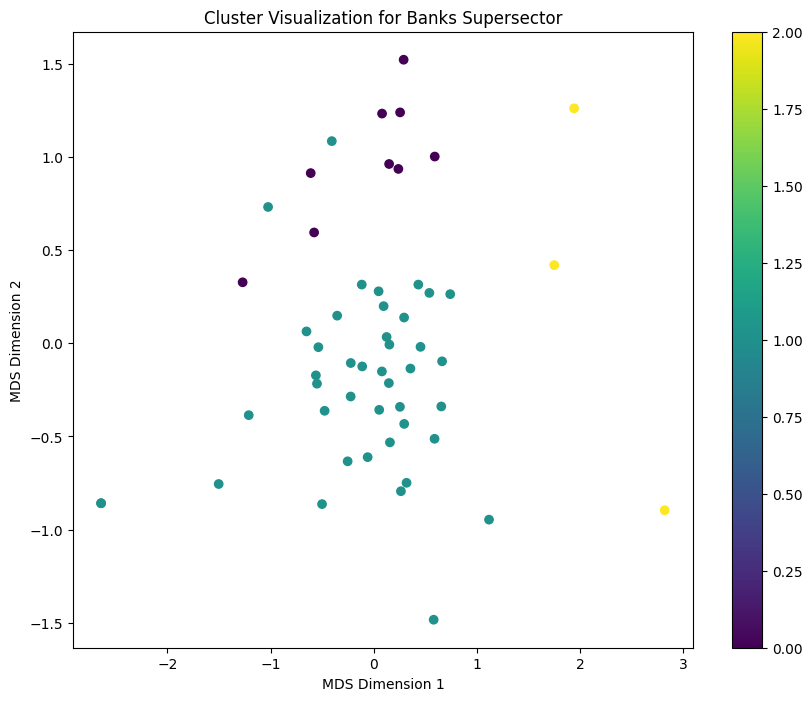

In [29]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import MDS
import numpy as np
import matplotlib.pyplot as plt


# Define a function to standardize data
def standardize_data(df):
    scaler = StandardScaler()
    # Replace infinities and drop any rows that still contain NaN after replacing
    df = df.replace([np.inf, -np.inf], np.nan).dropna()
    return scaler.fit_transform(df)

# Create a dictionary to store the results
cluster_dfs = {}

# Loop through each supersector to perform clustering
for supersector in data['Supersector'].unique():
    # Filter data for the current supersector
    sector_data = data[data['Supersector'] == supersector]
    
    # Pivot to get average scores by company and pillar, indexed by month
    pivot_data = sector_data.pivot_table(index=['month', 'Company Name Full'], columns='pillar', values='score', aggfunc='mean')
    
    # Calculate the monthly percentage change
    monthly_changes = pivot_data.groupby(level='Company Name Full').pct_change()
    monthly_changes.replace([np.inf, -np.inf], np.nan, inplace=True)
    monthly_changes.dropna(inplace=True)  # Remove rows with NaN values
    
    # Proceed only if there is enough data
    if not monthly_changes.empty:
        # Standardize the changes
        try:
            scaled_data = standardize_data(monthly_changes)
            
            # Perform clustering
            kmeans = KMeans(n_clusters=3, random_state=42)  # Adjust clusters as necessary
            clusters = kmeans.fit_predict(scaled_data)
            monthly_changes['Cluster'] = clusters
            
            # Add supersector info and store results
            monthly_changes['Supersector'] = supersector
            cluster_dfs[supersector] = monthly_changes.reset_index()
        except ValueError as e:
            print(f"Error processing supersector {supersector}: {e}")

# Visualize the clusters for the specific supersector "Banks"
if 'Banks' in cluster_dfs:
    banks_data = cluster_dfs['Banks']
    
    # Applying Multidimensional Scaling (MDS) to reduce dimensions for visualization
    mds = MDS(n_components=2, random_state=42)
    mds_result = mds.fit_transform(banks_data.drop(columns=['month', 'Company Name Full', 'Supersector', 'Cluster']))
    
    plt.figure(figsize=(10, 8))
    scatter = plt.scatter(mds_result[:, 0], mds_result[:, 1], c=banks_data['Cluster'], cmap='viridis')
    plt.title('Cluster Visualization for Banks Supersector')
    plt.xlabel('MDS Dimension 1')
    plt.ylabel('MDS Dimension 2')
    plt.colorbar(scatter)
    plt.show()
else:
    print("No data available for 'Banks' supersector")


Error processing supersector Real Estate: n_samples=1 should be >= n_clusters=3.
Error processing supersector Basic Resources: n_samples=1 should be >= n_clusters=3.


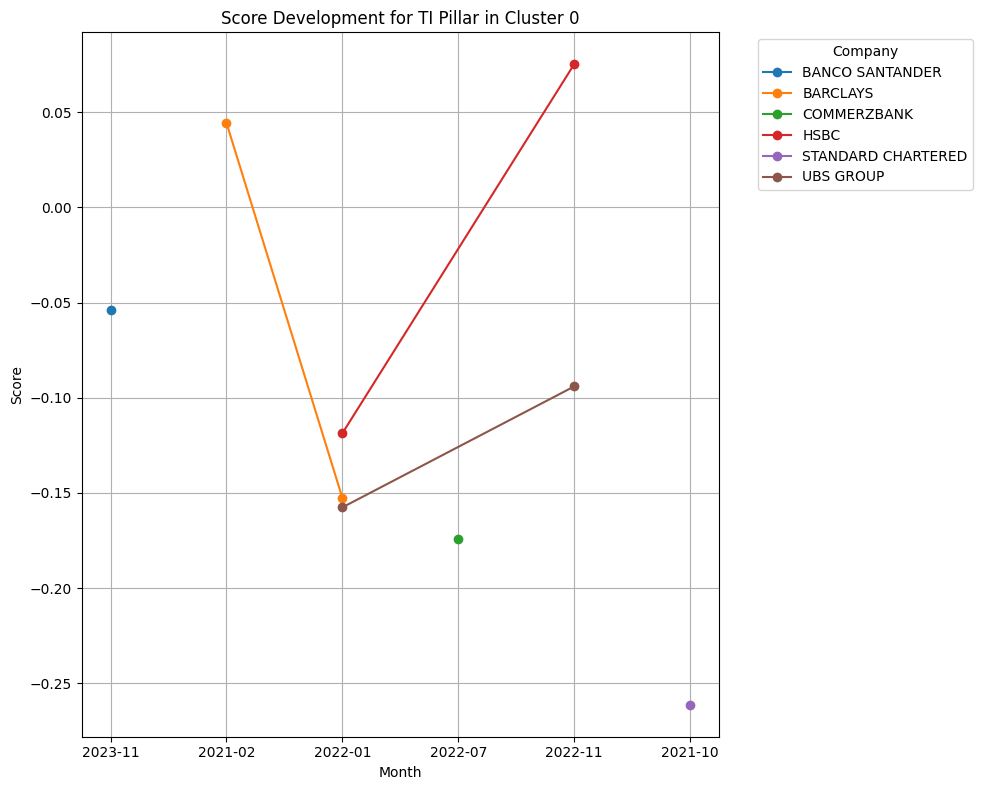

In [32]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np


# Choose the supersector and pillar you are interested in
supersector_interest = 'Banks'
pillar_interest = 'TI'  # Adjust this to the specific pillar you're interested in

# Define a function to standardize data
def standardize_data(df):
    scaler = StandardScaler()
    # Replace infinities and drop any rows that still contain NaN after replacing
    df = df.replace([np.inf, -np.inf], np.nan).dropna()
    return scaler.fit_transform(df)

# Create a dictionary to store the results
cluster_dfs = {}

# Loop through each supersector to perform clustering
for supersector in data['Supersector'].unique():
    # Filter data for the current supersector
    sector_data = data[data['Supersector'] == supersector]
    
    # Pivot to get average scores by company and pillar, indexed by month
    pivot_data = sector_data.pivot_table(index=['month', 'Company Name Full'], columns='pillar', values='score', aggfunc='mean')
    
    # Calculate the monthly percentage change
    monthly_changes = pivot_data.groupby(level='Company Name Full').pct_change()
    monthly_changes.replace([np.inf, -np.inf], np.nan, inplace=True)
    monthly_changes.dropna(inplace=True)  # Remove rows with NaN values
    
    # Proceed only if there is enough data
    if not monthly_changes.empty:
        # Standardize the changes
        try:
            scaled_data = standardize_data(monthly_changes)
            
            # Perform clustering
            kmeans = KMeans(n_clusters=3, random_state=42)  # Adjust clusters as necessary
            clusters = kmeans.fit_predict(scaled_data)
            monthly_changes['Cluster'] = clusters
            
            # Add supersector info and store results
            monthly_changes['Supersector'] = supersector
            cluster_dfs[supersector] = monthly_changes.reset_index()
        except ValueError as e:
            print(f"Error processing supersector {supersector}: {e}")

# Plotting the scores for a specific cluster in a specific supersector and pillar
if supersector_interest in cluster_dfs:
    # Filter for the supersector and cluster of interest
    supersector_data = cluster_dfs[supersector_interest]
    cluster_of_interest = 0  # Adjust as necessary
    
    # Filter data by cluster
    cluster_data = supersector_data[supersector_data['Cluster'] == cluster_of_interest]
    
    plt.figure(figsize=(10, 8))
    
    # Plot each company's score development for the selected pillar
    for idx, group in cluster_data.groupby('Company Name Full'):
        plt.plot(group['month'], group[pillar_interest], label=idx, marker='o')
    
    plt.title(f'Score Development for {pillar_interest} Pillar in Cluster {cluster_of_interest}')
    plt.xlabel('Month')
    plt.ylabel('Score')
    plt.legend(title='Company', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True)
    plt.tight_layout()
    plt.show()
else:
    print(f"No data available for supersector '{supersector_interest}'")


In [ ]:

# Grouping data by month and pillar, then calculating the mean of scores
trends = data_clean.groupby(['month', 'pillar']).agg({'score': 'mean'}).unstack()

# Plotting trends
plt.figure(figsize=(14, 7))
plt.plot(trends, marker='o')
plt.title('Trend of Digital Maturity Scores by Pillar Over Time')
plt.xlabel('Month')
plt.ylabel('Average Score')
plt.legend([col[1] for col in trends.columns], title='Pillar')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:

# Initialize an empty dictionary to store correlation matrices for each company
company_correlations = {}

# Calculate correlation for each company
for company in data_clean['Company Name Full'].unique():
    company_data = data_clean[data_clean['Company Name Full'] == company]
    if len(company_data) > 1:
        company_trends = company_data.groupby(['month', 'pillar']).agg({'score': 'mean'}).unstack()
        company_correlations[company] = company_trends.corr()

# Calculating the average correlation for each pair of pillars
if company_correlations:
    avg_correlation_matrix = pd.DataFrame(index=company_correlations[list(company_correlations.keys())[0]].index, 
                                          columns=company_correlations[list(company_correlations.keys())[0]].columns)

    for matrix in company_correlations.values():
        avg_correlation_matrix += matrix

    avg_correlation_matrix /= len(company_correlations)

avg_correlation_matrix


In [49]:
import pandas as pd

# Load the dataset
data = pd.read_csv('/Users/maxbreitruck/Library/CloudStorage/OneDrive-UniversitaetSt.Gallen/001_IWI/Dissertation/Paper#2/NLP-Practices/Pillar_scores.csv')

# Convert 'month' to datetime if it's not already
data['month'] = pd.to_datetime(data['month'])

# Check the first few rows to understand the data structure
print(data.head())


   Unnamed: 0 Company Name Full pillar         Supersector      month  \
0           0            3I GRP    BMI  Financial Services 2021-01-01   
1           1            3I GRP    BMI  Financial Services 2021-02-01   
2           2            3I GRP    BMI  Financial Services 2021-03-01   
3           3            3I GRP    BMI  Financial Services 2021-04-01   
4           4            3I GRP    BMI  Financial Services 2021-05-01   

   pillar_score  Overall Maturity Score  
0      0.052381                0.040931  
1      0.147619                0.075440  
2      0.176190                0.103879  
3      0.176190                0.105383  
4      0.176190                0.111011  


In [54]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import pandas as pd



# Assuming data loading and filtering have been done correctly
# Example filter (make sure it correctly references columns and values that exist)
filtered_data = data[(data['Supersector'] == 'Banks') & (data['pillar'] == 'TI')]

# Pivot to get scores as features
pivot_data = filtered_data.pivot_table(index='Company Name Full', columns='month', values='pillar_score')

# Check if pivot_data is empty
if pivot_data.empty:
    print("No data available after pivoting. Check your filters and data integrity.")
else:
    # Replace any potential non-numeric data with NaNs and drop rows with NaNs
    pivot_data = pivot_data.apply(pd.to_numeric, errors='coerce').dropna()

    # Check again if pivot_data is empty after dropping NaNs
    if pivot_data.empty:
        print("No data available after cleaning. All rows may have been dropped due to NaNs.")
    else:
        # Standardizing the data
        scaler = StandardScaler()
        scaled_data = scaler.fit_transform(pivot_data)

        # Clustering
        kmeans = KMeans(n_clusters=5, random_state=42)
        clusters = kmeans.fit_predict(scaled_data)
        pivot_data['Cluster'] = clusters

        # Outputting a sample to check
        print(pivot_data.head())


month              2021-01-01 00:00:00  2021-02-01 00:00:00  \
Company Name Full                                             
ABN AMRO                      0.274286             0.308571   
AVANZA BANK                   0.040000             0.040000   
BANCO SANTANDER               0.488571             0.488571   
BANKINTER                     0.091429             0.094286   
BARCLAYS                      0.580000             0.608571   

month              2021-03-01 00:00:00  2021-04-01 00:00:00  \
Company Name Full                                             
ABN AMRO                      0.331429             0.382857   
AVANZA BANK                   0.068571             0.068571   
BANCO SANTANDER               0.522857             0.562857   
BANKINTER                     0.094286             0.094286   
BARCLAYS                      0.674286             0.700000   

month              2021-05-01 00:00:00  2021-06-01 00:00:00  \
Company Name Full                                    

In [55]:
pivot_data.head()

month,2021-01-01 00:00:00,2021-02-01 00:00:00,2021-03-01 00:00:00,2021-04-01 00:00:00,2021-05-01 00:00:00,2021-06-01 00:00:00,2021-07-01 00:00:00,2021-08-01 00:00:00,2021-09-01 00:00:00,2021-10-01 00:00:00,...,2023-05-01 00:00:00,2023-06-01 00:00:00,2023-07-01 00:00:00,2023-08-01 00:00:00,2023-09-01 00:00:00,2023-10-01 00:00:00,2023-11-01 00:00:00,2023-12-01 00:00:00,2024-01-01 00:00:00,Cluster
Company Name Full,,,,,,,,,,,,,,,,,,,,,
ABN AMRO,0.274286,0.308571,0.331429,0.382857,0.385714,0.394286,0.397143,0.442857,0.442857,0.451429,...,0.531429,0.531429,0.531429,0.531429,0.531429,0.531429,0.531429,0.531429,0.531429,0
AVANZA BANK,0.040000,0.040000,0.068571,0.068571,0.068571,0.134286,0.157143,0.157143,0.157143,0.188571,...,0.245714,0.245714,0.245714,0.245714,0.245714,0.245714,0.245714,0.245714,0.245714,1
BANCO SANTANDER,0.488571,0.488571,0.522857,0.562857,0.565714,0.565714,0.565714,0.568571,0.568571,0.591429,...,0.640000,0.654286,0.654286,0.665714,0.665714,0.665714,0.665714,0.665714,0.665714,4
BANKINTER,0.091429,0.094286,0.094286,0.094286,0.122857,0.148571,0.148571,0.148571,0.148571,0.185714,...,0.260000,0.260000,0.268571,0.268571,0.282857,0.282857,0.297143,0.297143,0.297143,1
BARCLAYS,0.580000,0.608571,0.674286,0.700000,0.711429,0.711429,0.717143,0.717143,0.717143,0.717143,...,0.731429,0.731429,0.734286,0.734286,0.734286,0.734286,0.734286,0.734286,0.734286,2


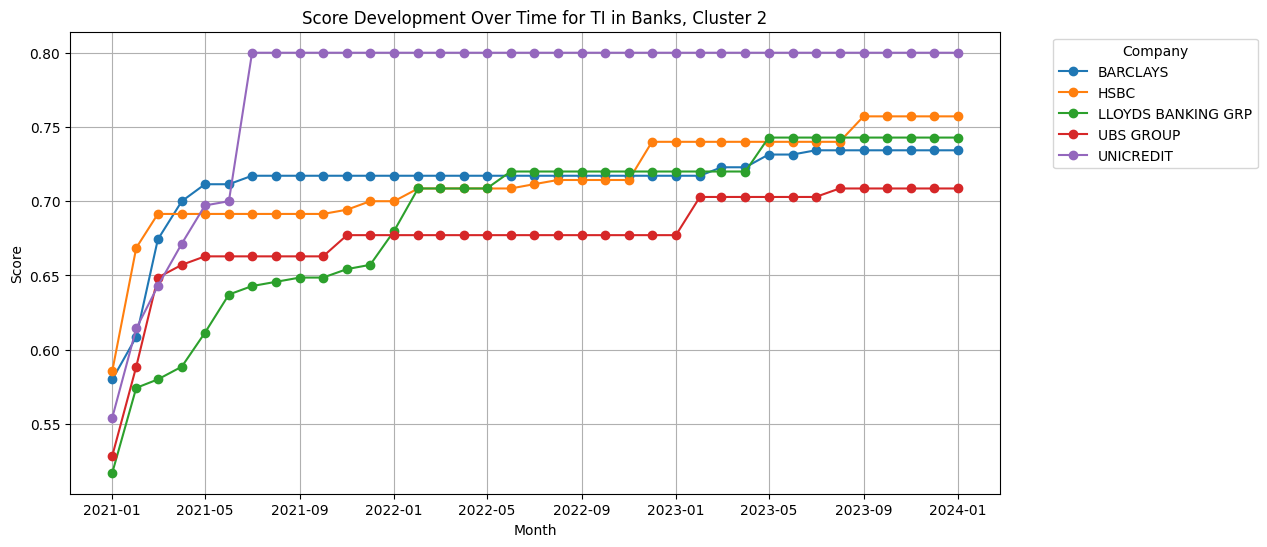

In [59]:
import matplotlib.pyplot as plt

# Define the cluster of interest for visualization
cluster_of_interest = 2  # You can change this to view different clusters

# Filter the pivot_data for the specific cluster
cluster_data = pivot_data[pivot_data['Cluster'] == cluster_of_interest]

# Plotting
plt.figure(figsize=(12, 6))
for company_name, scores in cluster_data.iterrows():
    # Drop the 'Cluster' column for plotting
    scores_filtered = scores.drop(labels='Cluster')
    plt.plot(scores_filtered.index, scores_filtered, marker='o', label=company_name)

plt.title(f'Score Development Over Time for TI in Banks, Cluster {cluster_of_interest}')
plt.xlabel('Month')
plt.ylabel('Score')
plt.legend(title='Company', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.show()


In [71]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import pandas as pd


# Filter data for a specific supersector
supersector_data = data[data['Supersector'] == 'Banks']  # Change 'Banks' to your supersector of interest

# Pivot the data to get scores as features for clustering
# Here, each company will have multiple columns for each combination of pillar and month
pivot_data = supersector_data.pivot_table(index='Company Name Full', 
                                          columns=['pillar', 'month'], 
                                          values='pillar_score', 
                                          aggfunc='mean')

# Fill missing values and handle infinite values
pivot_data.fillna(0, inplace=True)  # Assuming missing data can be treated as '0'
pivot_data.replace([np.inf, -np.inf], 0, inplace=True)  # Replace infinite values if any

# Standardizing the data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(pivot_data)

# Clustering
kmeans = KMeans(n_clusters=5, random_state=42)  # Adjust the number of clusters as necessary
clusters = kmeans.fit_predict(scaled_data)
pivot_data['Cluster'] = clusters

# Output some of the results to check
print(pivot_data['Cluster'].value_counts())
print(pivot_data.head())


NaT
1      13
3       9
0       6
2       5
4       4
Name: count, dtype: int64
pillar                   BMI                                              \
month             2021-01-01 2021-02-01 2021-03-01 2021-04-01 2021-05-01   
Company Name Full                                                          
ABN AMRO            0.266667   0.390476   0.509524   0.514286   0.514286   
AVANZA BANK         0.014286   0.014286   0.014286   0.014286   0.028571   
BANCO SANTANDER     0.380952   0.457143   0.533333   0.538095   0.580952   
BANKINTER           0.090476   0.128571   0.147619   0.152381   0.152381   
BARCLAYS            0.619048   0.809524   0.809524   0.809524   0.814286   

pillar                                                                    ...  \
month             2021-06-01 2021-07-01 2021-08-01 2021-09-01 2021-10-01  ...   
Company Name Full                                                         ...   
ABN AMRO            0.514286   0.523810   0.576190   0.576190   0.57

In [74]:
pivot_data.head(20)

pillar                      BMI                                              \
month                2021-01-01 2021-02-01 2021-03-01 2021-04-01 2021-05-01   
Company Name Full                                                             
ABN AMRO               0.266667   0.390476   0.509524   0.514286   0.514286   
AVANZA BANK            0.014286   0.014286   0.014286   0.014286   0.028571   
BANCO SANTANDER        0.380952   0.457143   0.533333   0.538095   0.580952   
BANKINTER              0.090476   0.128571   0.147619   0.152381   0.152381   
BARCLAYS               0.619048   0.809524   0.809524   0.809524   0.814286   
BAWAG GROUP            0.000000   0.057143   0.057143   0.076190   0.076190   
BNP PARIBAS            0.576190   0.609524   0.619048   0.619048   0.619048   
Banco BPM              0.023810   0.076190   0.095238   0.119048   0.142857   
Banco Bilbao           0.252381   0.276190   0.385714   0.419048   0.452381   
Banco de sabadell      0.109524   0.180952   0.185714   0.209524   0.257143   
CAIXABANK              0.223810   0.223810   0.328571   0.333333   0.333333   
CEMBRA                 0.023810   0.052381   0.057143   0.061905   0.061905   
COMMERZBANK            0.242857   0.261905   0.409524   0.438095   0.438095   
CREDIT AGRICOLE        0.328571   0.380952   0.380952   0.395238   0.433333   
DANSKE BANK            0.138095   0.161905   0.204762   0.280952   0.280952   
DNB                    0.123810   0.185714   0.195238   0.195238   0.200000   
ERSTE GROUP BANK       0.138095   0.195238   0.200000   0.204762   0.204762   
FINECOBANK             0.019048   0.052381   0.061905   0.123810   0.123810   
GRP SOCIETE GENERALE   0.409524   0.504762   0.523810   0.571429   0.623810   
HSBC                   0.585714   0.661905   0.671429   0.742857   0.742857   

pillar                                                                       \
month                2021-06-01 2021-07-01 2021-08-01 2021-09-01 2021-10-01   
Company Name Full                                                             
ABN AMRO               0.514286   0.523810   0.576190   0.576190   0.576190   
AVANZA BANK            0.028571   0.038095   0.066667   0.071429   0.133333   
BANCO SANTANDER        0.580952   0.580952   0.580952   0.580952   0.633333   
BANKINTER              0.152381   0.152381   0.152381   0.152381   0.152381   
BARCLAYS               0.814286   0.814286   0.842857   0.842857   0.842857   
BAWAG GROUP            0.090476   0.095238   0.095238   0.095238   0.095238   
BNP PARIBAS            0.623810   0.623810   0.747619   0.747619   0.747619   
Banco BPM              0.142857   0.161905   0.161905   0.161905   0.161905   
Banco Bilbao           0.461905   0.461905   0.476190   0.476190   0.476190   
Banco de sabadell      0.280952   0.280952   0.280952   0.280952   0.290476   
CAIXABANK              0.333333   0.333333   0.347619   0.352381   0.352381   
CEMBRA                 0.061905   0.076190   0.176190   0.176190   0.176190   
COMMERZBANK            0.438095   0.438095   0.438095   0.514286   0.514286   
CREDIT AGRICOLE        0.433333   0.433333   0.433333   0.433333   0.433333   
DANSKE BANK            0.295238   0.295238   0.295238   0.295238   0.323810   
DNB                    0.200000   0.252381   0.295238   0.295238   0.361905   
ERSTE GROUP BANK       0.204762   0.214286   0.214286   0.214286   0.223810   
FINECOBANK             0.123810   0.123810   0.123810   0.123810   0.152381   
GRP SOCIETE GENERALE   0.623810   0.623810   0.623810   0.623810   0.623810   
HSBC                   0.780952   0.780952   0.809524   0.809524   0.819048   

pillar                ...         TI                                   \
month                 ... 2023-05-01 2023-06-01 2023-07-01 2023-08-01   
Company Name Full     ...                                               
ABN AMRO              ...   0.531429   0.531429   0.531429   0.531429   
AVANZA BANK           ...   0.245714   0.245714   0.245714   0.245714   

In [82]:
import matplotlib.pyplot as plt
import pandas as pd

# Assuming 'pivot_data' is already created and structured with MultiIndex columns ('pillar', 'month')
# And that 'Cluster' information has been added as a column in 'pivot_data'

# Specify your choices
# The supersector of interest
cluster_of_interest = 2         # The cluster number of interest
pillar_of_interest = 'TI'       # The pillar of interest

# Ensure 'Cluster' is added to the pivot_data DataFrame
# This should be done in the clustering part of your code
# Example: pivot_data['Cluster'] = clusters (assuming clusters is your clustering result)

# Filter for the specific cluster and supersector (if not already filtered previously)
cluster_data = pivot_data[(pivot_data['NaT'] == cluster_of_interest)]

plt.figure(figsize=(12, 8))

# Plotting scores for the specified pillar for each company
for company_name, scores in cluster_data.iterrows():
    # Extracting scores for the selected pillar across all months
    # This step assumes you have a MultiIndex (pillar, month) on columns
    if (pillar_of_interest,) in scores.index.get_level_values(0).unique():
        scores_filtered = scores[pillar_of_interest]  # Directly accessing the MultiIndex for the pillar
        # Creating a series with months as index and scores as values
        scores_filtered = pd.Series(data=scores_filtered.values,
                                    index=pd.to_datetime([date for (pillar, date) in scores_filtered.index]))
        plt.plot(scores_filtered.index, scores_filtered, marker='o', label=company_name)

plt.title(f'Score Development for {pillar_of_interest} Pillar in Cluster {cluster_of_interest}')
plt.xlabel('Month')
plt.ylabel('Score')
plt.legend(title='Company', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.show()


KeyError: 'NaT'

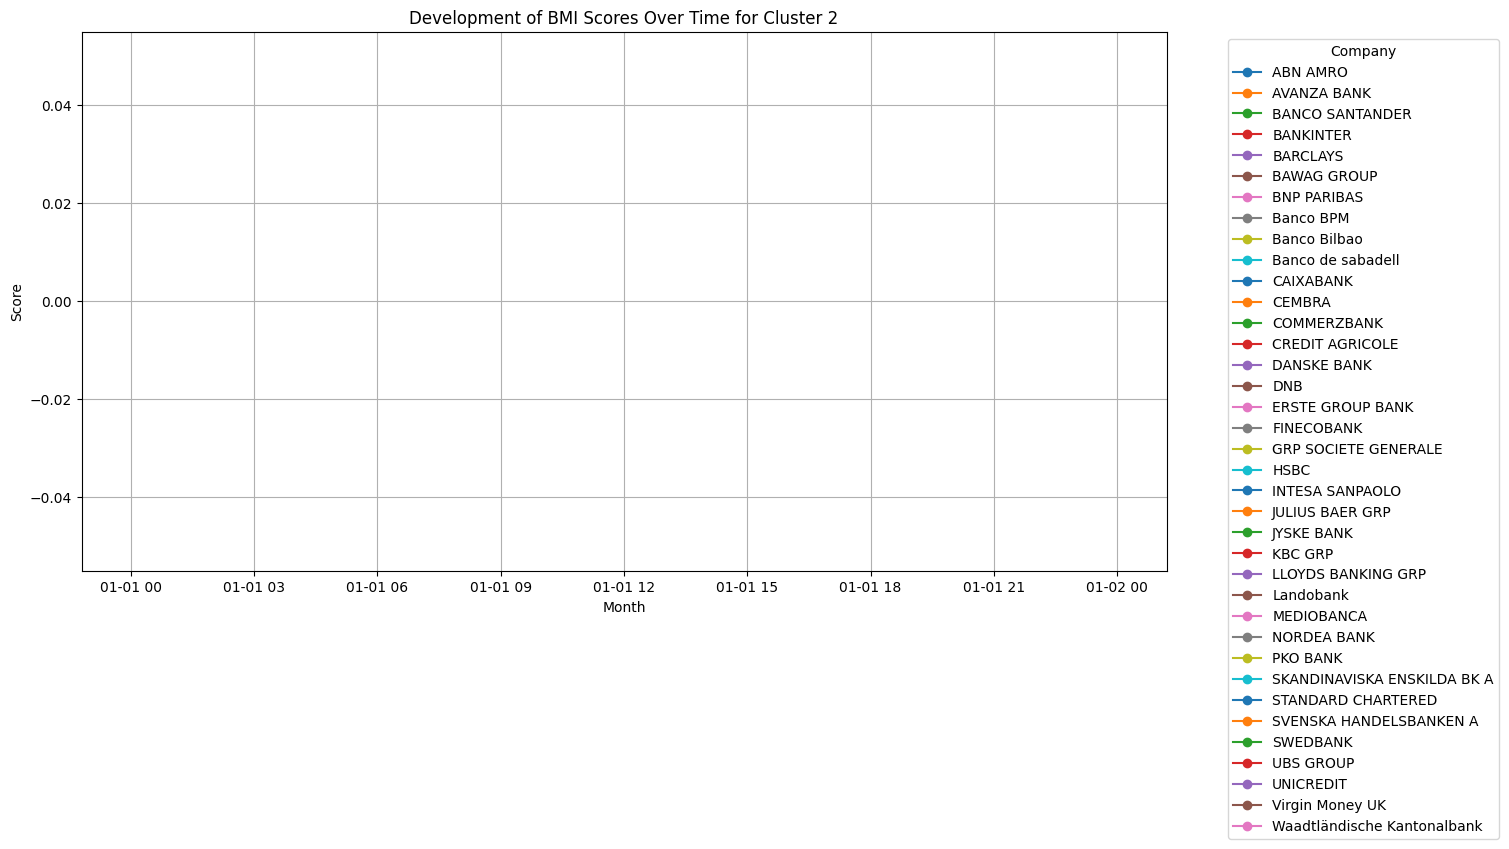

In [78]:
import matplotlib.pyplot as plt
import pandas as pd

# Define the cluster and pillar for visualization
cluster_of_interest = 2  # Adjust as needed
pillar_of_interest = 'BMI'  # Change to your specific pillar

# Filter the pivot_data for the specific cluster
cluster_data = pivot_data[pivot_data['Cluster'] == cluster_of_interest]

# Set up the figure for plotting
plt.figure(figsize=(14, 7))

# Plot each company's scores over time for the specified pillar
for company_name, data_row in cluster_data.iterrows():
    # Extract the scores for the specified pillar across all available months
    # The data for each company is accessed by specifying the pillar in the first level of the MultiIndex
    scores = data_row[pillar_of_interest].dropna()  # Drop NA to avoid breaks in the plot
    # Create a time series plot for the company
    plt.plot(scores.index, scores.values, marker='o', label=company_name)

# Set plot title and labels
plt.title(f"Development of {pillar_of_interest} Scores Over Time for Cluster {cluster_of_interest}")
plt.xlabel("Month")
plt.ylabel("Score")
plt.legend(title="Company", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True)
plt.show()


In [79]:
import pandas as pd

# Reset the index to turn the index into a regular column
pivot_data.reset_index(inplace=True)

# Create a new DataFrame that lists companies per cluster
# Group by 'Cluster' and aggregate the 'Company Name Full' into lists
companies_per_cluster = pivot_data.groupby('Cluster')['Company Name Full'].apply(list).reset_index()

# Display the DataFrame
print(companies_per_cluster)


ValueError: Grouper for 'Cluster' not 1-dimensional

In [80]:
import pandas as pd

# Check if 'Cluster' is part of the columns
if 'Cluster' not in pivot_data.columns:
    print("Adding 'Cluster' column again.")
    pivot_data['Cluster'] = clusters  # Ensure clusters are added to pivot_data

# Now let's reset the index to make sure 'Company Name Full' and all other columns are accessible
pivot_data.reset_index(inplace=True)

# Create a DataFrame that lists all companies per cluster
try:
    companies_per_cluster = pivot_data.groupby('Cluster')['Company Name Full'].apply(list).reset_index()
except Exception as e:
    print(f"Error during grouping: {e}")
    # Check what columns are available in pivot_data
    print("Columns in pivot_data:", pivot_data.columns)

# Display the DataFrame
print(companies_per_cluster)



Error during grouping: Grouper for 'Cluster' not 1-dimensional
Columns in pivot_data: MultiIndex([(            'index',        'NaT'),
            ('Company Name Full',        'NaT'),
            (              'BMI', '2021-01-01'),
            (              'BMI', '2021-02-01'),
            (              'BMI', '2021-03-01'),
            (              'BMI', '2021-04-01'),
            (              'BMI', '2021-05-01'),
            (              'BMI', '2021-06-01'),
            (              'BMI', '2021-07-01'),
            (              'BMI', '2021-08-01'),
            ...
            (               'TI', '2023-05-01'),
            (               'TI', '2023-06-01'),
            (               'TI', '2023-07-01'),
            (               'TI', '2023-08-01'),
            (               'TI', '2023-09-01'),
            (               'TI', '2023-10-01'),
            (               'TI', '2023-11-01'),
            (               'TI', '2023-12-01'),
            (   

NameError: name 'companies_per_cluster' is not defined